In [1]:
from sklearn import datasets
data_breast_cancer = datasets.load_breast_cancer()
X1 = data_breast_cancer.data

In [2]:
from sklearn.datasets import load_iris
data_iris = load_iris()
X2 = data_iris.data

In [3]:
from sklearn.decomposition import PCA

pca1 = PCA(n_components=0.9)
X1_90 = pca1.fit_transform(X1)
print(pca1.explained_variance_ratio_)

[0.98204467]


In [4]:
pca2 = PCA(n_components=0.9)
X2_90 = pca2.fit_transform(X2)
print(pca2.explained_variance_ratio_)

[0.92461872]


In [5]:
from sklearn.preprocessing import StandardScaler
import pickle

scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)

pca3 = PCA(n_components=0.9)
X1_scaled_90 = pca3.fit_transform(X1_scaled)
print(pca3.explained_variance_ratio_)

with open('pca_bc.pkl', 'wb') as f:
    pickle.dump(pca3.explained_variance_ratio_, f)

[0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734]


In [6]:
X2_scaled = scaler.fit_transform(X2)

pca4 = PCA(n_components=0.9)
X2_scaled_90 = pca4.fit_transform(X2_scaled)
print(pca4.explained_variance_ratio_)

with open('pca_ir.pkl', 'wb') as f:
    pickle.dump(pca4.explained_variance_ratio_, f)

[0.72962445 0.22850762]


In [7]:
import numpy as np

weighted_components1 = pca3.components_ * pca3.explained_variance_ratio_[:, np.newaxis]
feature_importance1 = np.sum(np.abs(weighted_components1), axis=0)
sorted_indices1 = np.argsort(feature_importance1)[::-1]
print(sorted_indices1)

with open('idx_bc.pkl', 'wb') as f:
    pickle.dump(sorted_indices1, f)

[13 25 10 12 15 29 26  4 17  2  0 24  3 22 20 16 23  5 28 19  8  7 27  6
 18  9 14 21  1 11]


In [8]:
weighted_components2 = pca4.components_ * pca4.explained_variance_ratio_[:, np.newaxis]
feature_importance2 = np.sum(np.abs(weighted_components2), axis=0)
sorted_indices2 = np.argsort(feature_importance2)[::-1]
print(sorted_indices2)

with open('idx_ir.pkl', 'wb') as f:
    pickle.dump(sorted_indices2, f)

[0 2 3 1]


In [9]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data

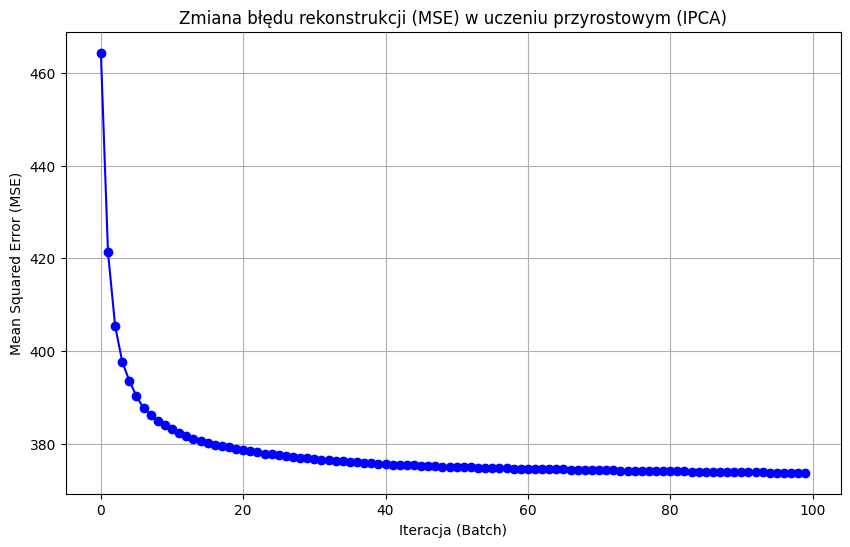

In [10]:
from sklearn.decomposition import IncrementalPCA
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

n_batches = 100
inc_pca = IncrementalPCA(n_components=100)
mse_history = []

for X_batch in np.array_split(X, n_batches):
    inc_pca.partial_fit(X_batch)
    X_recovered = inc_pca.inverse_transform(inc_pca.transform(X))
    mse = mean_squared_error(X, X_recovered)
    mse_history.append(mse)                                     
                                            
X_reduced = inc_pca.transform(X)
inc_pca_mse = [mse_history[0], mse_history[-1]]
with open('inc_pca_mse.pkl', 'wb') as f:
    pickle.dump(inc_pca_mse, f)

plt.figure(figsize=(10, 6))
plt.plot(mse_history, marker='o', linestyle='-', color='b')
plt.title('Zmiana błędu rekonstrukcji (MSE) w uczeniu przyrostowym (IPCA)')
plt.xlabel('Iteracja (Batch)')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.show()


In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100, svd_solver='randomized')
X_reduced = pca.fit_transform(X)
X_recovered = pca.inverse_transform(X_reduced)

pca_mse_value = mean_squared_error(X, X_recovered)
pca_mse_list = [pca_mse_value]
with open('pca_mse.pkl', 'wb') as f:
    pickle.dump(pca_mse_list, f)

print(f"Błąd MSE dla PCA: {pca_mse_value}")

Błąd MSE dla PCA: 373.7603485883745


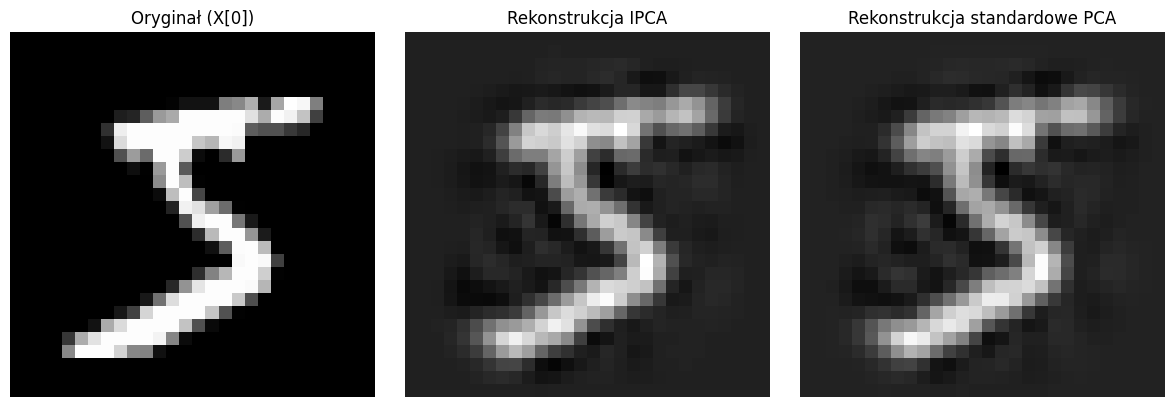

In [12]:
digit_original = X[0]

digit_reduced_ipca = inc_pca.transform(digit_original.reshape(1, -1))
digit_recovered_ipca = inc_pca.inverse_transform(digit_reduced_ipca)

digit_reduced_pca = pca.transform(digit_original.reshape(1, -1))
digit_recovered_pca = pca.inverse_transform(digit_reduced_pca)

img_original = digit_original.reshape(28, 28)
img_ipca = digit_recovered_ipca.reshape(28, 28)
img_pca = digit_recovered_pca.reshape(28, 28)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_original, cmap='gray')
axes[0].set_title('Oryginał (X[0])')
axes[0].axis('off')

axes[1].imshow(img_ipca, cmap='gray')
axes[1].set_title('Rekonstrukcja IPCA')
axes[1].axis('off')

axes[2].imshow(img_pca, cmap='gray')
axes[2].set_title('Rekonstrukcja standardowe PCA')
axes[2].axis('off')

plt.tight_layout()
plt.show()